## Problem 1
### Part 1

In [1]:
# symbolic computation tools
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff, eye
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve, minimize
from sympy import init_printing
init_printing() 

def cross_matrix(vec):
    return np.matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    return np.matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    return(m)

def inv(T):
    T_0_inv = Matrix.zeros(4,4)
    T_0_inv[0:3, 0:3] = T[0:3,0:3].T
    T_0_inv[0:3, 3] = -T[0:3,0:3].T @ T[0:3,3]
    T_0_inv[3, 3] = 1
    return T_0_inv
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])
    
def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m
    
def plot_transform(T, ax):
    origin = T[0:3, 3]
    sc = 0.5
    
    ax.plot([origin[0], sc*T[0,0]+origin[0]], 
            [origin[1], sc*T[1,0]+origin[1]], 
            [origin[2], sc*T[2,0]+origin[2]], 
            color='red', linestyle='-', marker='o', linewidth=5)
    ax.plot([origin[0], sc*T[0,1]+origin[0]], 
            [origin[1], sc*T[1,1]+origin[1]], 
            [origin[2], sc*T[2,1]+origin[2]], 
            color='green', linestyle='-', marker='o', linewidth=5)
    # ax.plot([origin[0], T[0,2]+origin[0]], 
    #         [origin[1], T[1,2]+origin[1]], 
    #         [origin[2], T[2,2]+origin[2]], 
    #         color='blue', linestyle='-', marker='o', linewidth=5)
    
    
def plot_bot(Tb, T1, T2, w_, ax):
    plot_transform(T(eye(3), Matrix([[0], [0], [0]])), ax)

    plot_transform(Tb, ax)
    plot_transform(T1, ax)
    plot_transform(T2, ax)
    
    j1 = Tb @ T(eye(3), Matrix([[-w_], [0], [0]]))
    j2 = Tb @ T(eye(3), Matrix([[w_], [0], [0]]))
    e1 = T1 @ T(eye(3), Matrix([[w_], [0], [0]]))
    e2 = T2 @ T(eye(3), Matrix([[w_], [0], [0]]))
    
    ax.plot([Tb[0,3], j1[0,3]], [Tb[1,3], j1[1,3]], 'ko-', markersize = 8)
    ax.plot([Tb[0,3], j2[0,3]], [Tb[1,3], j2[1,3]], 'ko-', markersize = 8)
    
    ax.plot([j1[0,3], T1[0,3]], [j1[1,3], T1[1,3]], 'ko-')
    ax.plot([j2[0,3], T2[0,3]], [j2[1,3], T2[1,3]], 'ko-')
    
    ax.plot([e1[0,3], T1[0,3]], [e1[1,3], T1[1,3]], 'ko-')
    ax.plot([e2[0,3], T2[0,3]], [e2[1,3], T2[1,3]], 'ko-')
    

### Configuration

In [2]:
##### Geometry
t = symbols("t" , real = True)
l = symbols("l" , real = True)
w = symbols("w" , real = True)
m = symbols("m" , real = True)
k = symbols("k" , real = True)

##### Configuration variables
alpha_1 = Function('alpha_1', real=True)(t)
alpha_2 = Function('alpha_2', real=True)(t)
x = Function('x', real=True)(t)
y = Function('y', real=True)(t)
theta = Function('theta', real=True)(t)

##### Alpha kinematics variabls
omega = symbols("omega" , real = True)
A1 = symbols("A1" , real = True)
A2 = symbols("A2" , real = True)
phi = symbols("phi" , real = True)

### Transformations, Body Twists, and Jacobians

In [3]:
T_0 = T(eye(3), Matrix([[0], [0], [0]]))
T_0b = T(R_z(theta), Matrix([[x], [y], [0]]))
T_01 = simplify(T_0b @ T(R_z(pi + alpha_1), Matrix([[-w], [0], [0]])) @ T(eye(3), Matrix([[w], [0], [0]])))
T_02 = simplify(T_0b @ T(R_z(alpha_2), Matrix([[w], [0], [0]])) @ T(eye(3), Matrix([[w], [0], [0]])))

q = [x, y, theta, alpha_1, alpha_2]
q_dt = [Derivative(qq, t) for qq in q]
q_dtdt = [Derivative(qq, t, t) for qq in q]


body_twist_0b = inv(T_0b) @ diff(T_0b, t)
body_twist_0b = simplify(body_twist_0b)
body_twist_0b

body_twist_01 = inv(T_01) @ diff(T_01, t)
body_twist_01 = simplify(body_twist_01)
body_twist_01

body_twist_02 = inv(T_02) @ diff(T_02, t)
body_twist_02 = simplify(body_twist_02)
body_twist_02

v_0b = twist2vec(body_twist_0b)
v_01 = twist2vec(body_twist_01)
v_02 = twist2vec(body_twist_02)

J_0b = v_0b.jacobian(q_dt)
J_01 = v_01.jacobian(q_dt)
J_02 = v_02.jacobian(q_dt)

In [4]:
B      = -Matrix([[0, 0, 0,          0, 0, 0],
                 [0, 0, 0,          0, 0, 0],
                 [0, 0, 2/3*k*l**3, 0, 0, 0],
                 [0, 0, 0, k*l,     0,    0],
                 [0, 0, 0, 0, 2*k*l,      0],
                 [0, 0, 0, 0, 0,          0]])

A = J_0b.T @ B @ J_0b + J_01.T @ B @ J_01 + J_02.T @ B @ J_02
simplify(A)
def B(t, q, q_dt, params):
    return -np.linalg.inv(A_11_lambda(0, q, q_dt, params)) @ A_12_lambda(0, q, q_dt, params)

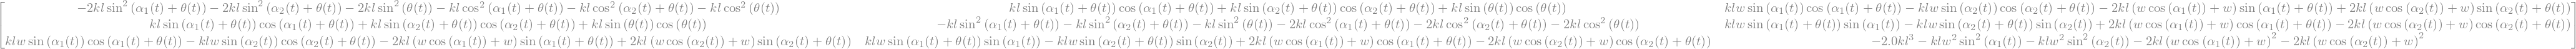

In [5]:
A_11 = A[0:3, 0:3]
A_11

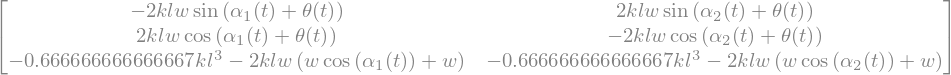

In [6]:
A_12 = A[0:3, 3:]
A_12

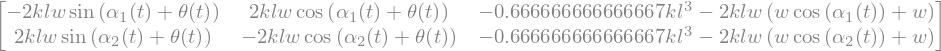

In [7]:
A_21 = A[3:, 0:3]
A_21

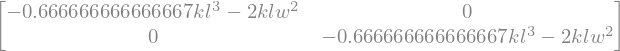

In [8]:
A_22 = A[3:, 3:]
A_22

In [9]:
params = [l, w, m, k, A1, A2, omega, phi]

A_11_lambda       =   lambdify([t, q, q_dt, params], A_11)
A_12_lambda       =   lambdify([t, q, q_dt, params], A_12)


In [10]:
params_ = [1, 1/2, 1, 1, 0, 0, 0, 0]

q_    = [0, 0, 0, 0, np.pi/8]
q_dt_ = [0, 0, 0, 0, 0]

np.linalg.inv(A_11_lambda(0, q_, q_dt_, params_))

array([[-0.32571556, -0.0204761 , -0.03147179],
       [-0.0204761 , -0.17223427, -0.00631493],
       [-0.03147179, -0.00631493, -0.173009  ]])

In [11]:
B(0, q_, q_dt_, params_)

array([[-0.03197688,  0.05447334],
       [ 0.16170939, -0.16157239],
       [-0.2820334 , -0.27555407]])

### Part 2 Foruier Functions

In [12]:
def fourier_gate(coefficients, t, params):
    ### Returns a1, a2, a1_dot, a2_dot
    ### Coefficients is a 4*N x 1 vector of a_n, b_n, c_n, d_n in that order
    N = int(len(coefficients) / 4)
    
    a = coefficients[0*N : 1*N]
    b = coefficients[1*N : 2*N]
    c = coefficients[2*N : 3*N]
    d = coefficients[3*N : 4*N]
    omega_ = params[6]  # pull omega out of params list
    
    alpha_1     = 0.0
    alpha_2     = 0.0
    alpha_1_dot = 0.0
    alpha_2_dot = 0.0
    
    for n in range(1, N + 1):
        wn = n * omega_
        alpha_1     +=  a[n-1] * np.cos(wn * t) + b[n-1] * np.sin(wn * t)
        alpha_2     +=  c[n-1] * np.cos(wn * t) + d[n-1] * np.sin(wn * t)
        alpha_1_dot += -a[n-1] * wn * np.sin(wn * t) + b[n-1] * wn * np.cos(wn * t)
        alpha_2_dot += -c[n-1] * wn * np.sin(wn * t) + d[n-1] * wn * np.cos(wn * t)
    return alpha_1, alpha_2, alpha_1_dot, alpha_2_dot

In [13]:
def dynamics(t, state, params, coefficients):
    x, y, theta = state
    
    alpha0, alpha1, alpha0_dt, alpha1_dt = fourier_gate(coefficients, t, params)
    
    q_    = [x, y, theta, alpha0, alpha1]
    q_dt_ = [0, 0, 0, 0, 0]
        
    dydt = B(t, q_, q_dt_, params_) @ np.matrix([[alpha0_dt], [alpha1_dt]])
    
    return dydt.flatten().tolist()[0]            

In [14]:
def gait_cycle(coefficients, params, T=2*np.pi):
    
    ########## Your code here
    omega_ = params[6]
    T = 2 * np.pi / omega_ if omega_ != 0 else T  # one full period
    
    state0 = [0.0, 0.0, 0.0]  # x, y, theta initial conditions
    
    sol = solve_ivp(
        dynamics,
        [0, T],
        state0,
        args=(params, coefficients),
        dense_output=True,
        max_step=T / 200
    )
    
    time = sol.t
    x_sol     = sol.y[0]
    y_sol     = sol.y[1]
    theta_sol = sol.y[2]
    
    # Reconstruct alpha and alpha_dot at each time point
    alpha_1_sol     = np.zeros(len(time))
    alpha_2_sol     = np.zeros(len(time))
    alpha_1_dot_sol = np.zeros(len(time))
    alpha_2_dot_sol = np.zeros(len(time))
    
    for i, ti in enumerate(time):
        a1, a2, a1d, a2d = fourier_gate(coefficients, ti, params)
        alpha_1_sol[i]     = a1
        alpha_2_sol[i]     = a2
        alpha_1_dot_sol[i] = a1d
        alpha_2_dot_sol[i] = a2d
    
    # Reconstruct body velocities from dynamics
    x_dot_sol     = np.zeros(len(time))
    y_dot_sol     = np.zeros(len(time))
    theta_dot_sol = np.zeros(len(time))
    
    for i, ti in enumerate(time):
        dstate = dynamics(ti, sol.y[:, i], params, coefficients)
        x_dot_sol[i]     = dstate[0]
        y_dot_sol[i]     = dstate[1]
        theta_dot_sol[i] = dstate[2]

    return time, x_sol, y_sol, theta_sol, alpha_1_sol, alpha_2_sol, \
           x_dot_sol, y_dot_sol, theta_dot_sol, alpha_1_dot_sol, alpha_2_dot_sol

In [15]:
l_ = 2
w_ = 1
m_ = 1
k_ = 1

A1_ = 0
A2_ = 0
omega_ = 1
phi_ = 0

params_ = [l_, w_, m_, k_, A1_, A2_, omega_, phi_]
coefficients = [1, 0, 0, 1, .5, .5, .5, .5]


time, x_sol, y_sol, theta_sol, alpha_1_sol, alpha_2_sol, \
x_dot_sol, y_dot_sol, theta_dot_sol, alpha_1_dot_sol, alpha_2_dot_sol = gait_cycle(coefficients, params_)


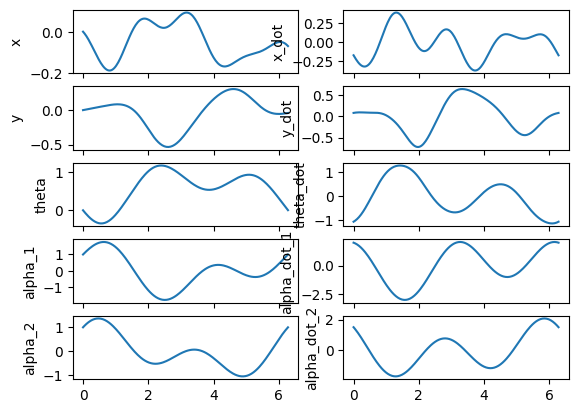

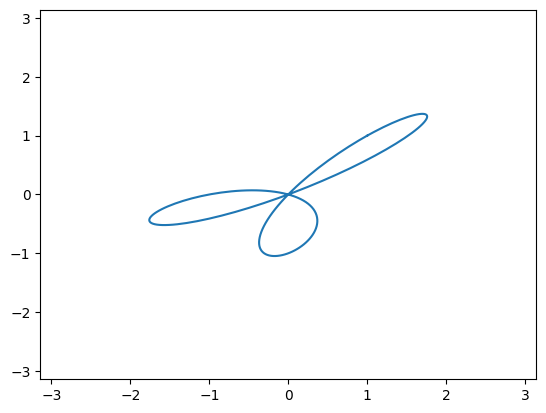

In [16]:
fig = plt.figure(1)
fig.clf()
ax = fig.subplots(5, 2, sharex = True)

ax[0][0].plot(time, x_sol)
ax[0][0].set_ylabel('x')
ax[1][0].plot(time, y_sol)
ax[1][0].set_ylabel('y')
ax[2][0].plot(time, theta_sol)
ax[2][0].set_ylabel('theta')
ax[3][0].plot(time, alpha_1_sol)
ax[3][0].set_ylabel('alpha_1')
ax[4][0].plot(time, alpha_2_sol)
ax[4][0].set_ylabel('alpha_2')

ax[0][1].plot(time, x_dot_sol)
ax[0][1].set_ylabel('x_dot')
ax[1][1].plot(time, y_dot_sol)
ax[1][1].set_ylabel('y_dot')
ax[2][1].plot(time, theta_dot_sol)
ax[2][1].set_ylabel('theta_dot')
ax[3][1].plot(time, alpha_1_dot_sol)
ax[3][1].set_ylabel('alpha_dot_1')
ax[4][1].plot(time, alpha_2_dot_sol)
ax[4][1].set_ylabel('alpha_dot_2')
# plt.gcf()
plt.figure(10)

plt.plot(alpha_1_sol, alpha_2_sol)
plt.gca().axis([-np.pi, np.pi, -np.pi, np.pi])

### Part 3 Gait Optimization

In [17]:
def cost_of_transport(coefficients, params):
    """
    CoT = Energy / Distance
    Energy ~ integral of |alpha_dot|^2 dt (actuator effort proxy)
    Distance = net forward displacement after one cycle
    """
    try:
        time, x_sol, y_sol, theta_sol, _, _, \
        x_dot_sol, y_dot_sol, theta_dot_sol, a1_dot_sol, a2_dot_sol = gait_cycle(coefficients, params)
    except Exception:
        return 1e6  # penalize failed simulations

    # Energy = integral of squared joint velocities (actuator power proxy)
    energy = np.trapezoid(a1_dot_sol**2 + a2_dot_sol**2, time)

    # Net forward displacement (in body x-direction at start, theta=0 => world x)
    distance = x_sol[-1]

    if abs(distance) < 1e-6:
        return 1e6  # penalize if robot doesn't move

    return energy / distance  # minimize this


def neg_forward_distance(coefficients, params):
    """Negative forward distance (so minimizing this = maximizing distance)."""
    try:
        time, x_sol, *_ = gait_cycle(coefficients, params)
    except Exception:
        return 1e6
    return -x_sol[-1]  # negate to turn max into min problem

In [18]:
# Starting coefficients (your hand-designed gait as initial guess)
# N=2 harmonics: [a1, a2, b1, b2, c1, c2, d1, d2]
coeff0 = np.array([1, 0, 0, 1, 0.5, 0.5, 0.5, 0.5])

l_ = 2; w_ = 1; m_ = 1; k_ = 1
omega_ = 1; phi_ = 0
params_ = [l_, w_, m_, k_, 0, 0, omega_, phi_]

# --- Optimization 1: Maximize forward distance ---
result_dist = minimize(
    neg_forward_distance,
    coeff0,
    args=(params_,),
    method='Nelder-Mead',          # gradient-free, robust for noisy sims
    options={'maxiter': 500, 'xatol': 1e-4, 'fatol': 1e-4, 'disp': True}
)
coeffs_opt_dist = result_dist.x
print(f"Max distance achieved: {-result_dist.fun:.4f}")

# --- Optimization 2: Minimize cost of transport ---
result_cot = minimize(
    cost_of_transport,
    coeff0,
    args=(params_,),
    method='Nelder-Mead',
    options={'maxiter': 500, 'xatol': 1e-4, 'fatol': 1e-4, 'disp': True}
)
coeffs_opt_cot = result_cot.x
print(f"Min CoT achieved: {result_cot.fun:.4f}")

C:\Users\Ryan\AppData\Local\Temp\ipykernel_101928\237187217.py:10: RuntimeWarning: Maximum number of iterations has been exceeded.
  result_dist = minimize(


Max distance achieved: 3.0513
Min CoT achieved: -20005599.7399


C:\Users\Ryan\AppData\Local\Temp\ipykernel_101928\237187217.py:21: RuntimeWarning: Maximum number of iterations has been exceeded.
  result_cot = minimize(


  Hand-designed | dist=-0.0701 | CoT=-335.9201
   Max Distance | dist=+3.0513 | CoT=190.4013
        Min CoT | dist=-0.0000 | CoT=-20005599.7399


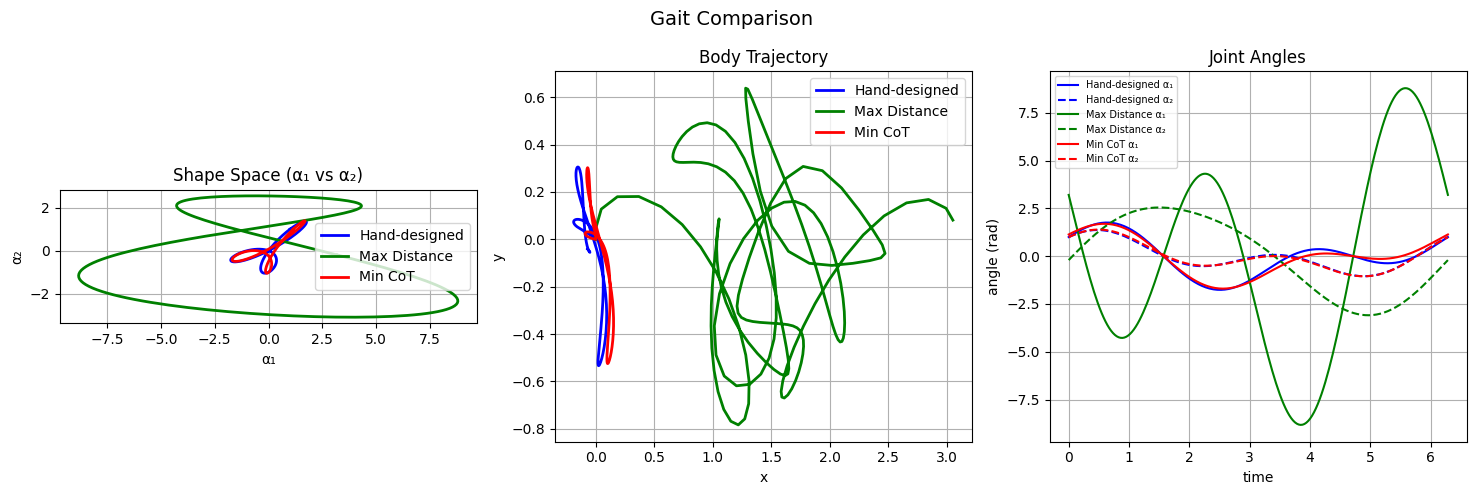

In [19]:
def compare_gaits(coeff0, coeffs_opt_dist, coeffs_opt_cot, params_):
    labels   = ['Hand-designed', 'Max Distance', 'Min CoT']
    coeffs   = [coeff0, coeffs_opt_dist, coeffs_opt_cot]
    colors   = ['blue', 'green', 'red']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Gait Comparison", fontsize=14)

    for label, c, col in zip(labels, coeffs, colors):
        time, x_sol, y_sol, theta_sol, a1_sol, a2_sol, \
        xd, yd, td, a1d, a2d = gait_cycle(c, params_)

        energy   = np.trapezoid(a1d**2 + a2d**2, time)
        distance = x_sol[-1]
        cot      = energy / distance if abs(distance) > 1e-6 else np.inf

        print(f"{label:>15} | dist={distance:+.4f} | CoT={cot:.4f}")

        # Shape space gait curve
        axes[0].plot(a1_sol, a2_sol, color=col, label=label, lw=2)

        # Body trajectory
        axes[1].plot(x_sol, y_sol, color=col, label=label, lw=2)

        # Joint angles
        axes[2].plot(time, a1_sol, color=col, linestyle='-',  label=f'{label} α₁', lw=1.5)
        axes[2].plot(time, a2_sol, color=col, linestyle='--', label=f'{label} α₂', lw=1.5)

    axes[0].set_title("Shape Space (α₁ vs α₂)")
    axes[0].set_xlabel("α₁"); axes[0].set_ylabel("α₂")
    axes[0].legend(); axes[0].grid(True); axes[0].set_aspect('equal')

    axes[1].set_title("Body Trajectory")
    axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
    axes[1].legend(); axes[1].grid(True)

    axes[2].set_title("Joint Angles")
    axes[2].set_xlabel("time"); axes[2].set_ylabel("angle (rad)")
    axes[2].legend(fontsize=7); axes[2].grid(True)

    plt.tight_layout()
    plt.show()

compare_gaits(coeff0, coeffs_opt_dist, coeffs_opt_cot, params_)